# Week 12 — Bayesian Optimization

In [1]:
import numpy as np
import warnings
import sys
import importlib
sys.path.append('..')

import utils.bayesian_optimization
importlib.reload(utils.bayesian_optimization)
from utils.bayesian_optimization import propose_next_point, fit_gp, get_strategy

from utils.data_utils import (
    load_week_data,
    save_week_data,
    combine_with_week_results, 
    print_data_summary
)

## 1. Load Week 11 Data & Add Results

In [2]:
inputs, outputs = load_week_data("../week 11/week11_clean_data.npz")
print_data_summary(inputs, outputs, "Week 11 Data")

# Week 11 submitted points
week11_inputs = {
    1: np.array([0.433000, 0.425000]),
    2: np.array([0.550000, 0.500000]),
    3: np.array([0.347863, 0.672420, 0.447172]),
    4: np.array([0.413690, 0.372443, 0.360391, 0.413441]),
    5: np.array([1.000000, 1.000000, 0.000000, 0.000000]),
    6: np.array([0.755469, 0.275580, 0.644099, 0.672028, 0.162862]),
    7: np.array([0.000000, 0.306263, 0.707844, 0.246481, 0.405689, 0.758028]),
    8: np.array([0.107475, 0.120302, 0.100000, 0.207071, 1.000000, 0.099881, 0.180000, 0.998620])
}

# Week 11 outputs
week11_outputs = {
    1: 0.7020707420409252,
    2: 0.23998955440764258,
    3: -0.008216816115161733,
    4: 0.6942276328080337,
    5: 1616.6425,
    6: -0.5706637064140012,
    7: 1.8786635954772637,
    8: 9.796264173904
}

inputs, outputs = combine_with_week_results(inputs, outputs, week11_inputs, week11_outputs)
print_data_summary(inputs, outputs, "After Week 11 Results")


Data loaded from ../week 11/week11_clean_data.npz

Week 11 Data:
  Function 1: 20 points, 2D, best = 0.964835
  Function 2: 20 points, 2D, best = 0.613847
  Function 3: 25 points, 3D, best = -0.004616
  Function 4: 40 points, 4D, best = 0.724314
  Function 5: 30 points, 4D, best = 8662.482500
  Function 6: 30 points, 5D, best = -0.520742
  Function 7: 40 points, 6D, best = 1.874193
  Function 8: 50 points, 8D, best = 9.788164

After Week 11 Results:
  Function 1: 21 points, 2D, best = 0.964835
  Function 2: 21 points, 2D, best = 0.613847
  Function 3: 26 points, 3D, best = -0.004616
  Function 4: 41 points, 4D, best = 0.724314
  Function 5: 31 points, 4D, best = 8662.482500
  Function 6: 31 points, 5D, best = -0.520742
  Function 7: 41 points, 6D, best = 1.878664
  Function 8: 51 points, 8D, best = 9.796264


In [3]:
save_week_data(inputs, outputs, "week12_clean_data.npz")


Data saved to week12_clean_data.npz


## 2. Week 11 Results Analysis

In [4]:
print("=" * 70)
print("WEEK 11 RESULTS ANALYSIS")
print("=" * 70)

best_before = {}
for fid in range(1, 9):
    best_before[fid] = np.max(outputs[fid][:-1])

print(f"\n{'F':>2} {'Dims':>4} {'Best Before W11':>15} {'W11 Query':>14} {'New Best':>14} {'Status'}")
print("-" * 75)

improved = 0
for fid in range(1, 9):
    dim = inputs[fid].shape[1]
    prev_best = best_before[fid]
    w11_val = week11_outputs[fid]
    new_best = np.max(outputs[fid])
    
    if w11_val >= prev_best:
        status = "NEW BEST"
        improved += 1
    else:
        status = f"miss (best still {prev_best:.4f})"
    
    print(f"{fid:>2} {dim:>3}D {prev_best:>15.4f} {w11_val:>14.4f} {new_best:>14.4f}   {status}")

print(f"\nWeek 11 hit rate: {improved}/8 functions improved")
print("=" * 70)

print("\n" + "=" * 70)
print("WEEK 11 STRATEGY EVALUATION")
print("=" * 70)

strategies = {
    1: ("DOUBLE STEP dim1+0.010", "BIG MISS 0.702 vs best 0.965. dim1+0.010 overshot! Spike is asymmetric — dim1 more sensitive than dim2. Revert to dim2+0.010 ONLY."),
    2: ("LAST GAP [0.55, 0.50]", "MISS 0.240. Better than 0.20 and 0.45 but still dead. dim1=0.55-0.67 partially explored. Second peak elusive."),
    3: ("CONTINUE dim3+0.004", "MISS -0.0082 vs best -0.0046. Overshot! W10 dim3=0.443 was better. Optimum between 0.439-0.447, near 0.443. Halve step."),
    4: ("SAFE DIM dim2+0.005", "MISS 0.694 vs best 0.724. dim2 increase also wrong. dim2=0.367 may be optimal."),
    5: ("BOLD [1,1,0,0]", "INFO: 1617 = same as [0,0,1,1]! Function is SYMMETRIC between (dim1,dim2) and (dim3,dim4) pairs."),
    6: ("REVERSE dim4-0.0002", "MISS -0.571 vs best -0.521. BOTH dim4 directions fail. dim4=0.672228 IS the optimum. Don't touch dim4."),
    7: ("CONTINUE dim2-0.003", "NEW BEST +0.004 (1.874→1.879). 6th CONSECUTIVE! Unstoppable."),
    8: ("CONTINUE dim3+0.030", "NEW BEST +0.008 (9.788→9.796). 3rd consecutive dim3 win. Gap to peer: 0.16.")
}

for fid in range(1, 9):
    strategy, evaluation = strategies[fid]
    print(f"\nF{fid}: {strategy}")
    print(f"  → {evaluation}")

print(f"\n{'=' * 70}")
print("SUMMARY: 2/8 new bests (F7, F8). F1 overshot badly. F6 dim4 confirmed at optimum.")
print("=" * 70)

WEEK 11 RESULTS ANALYSIS

 F Dims Best Before W11      W11 Query       New Best Status
---------------------------------------------------------------------------
 1   2D          0.9648         0.7021         0.9648   miss (best still 0.9648)
 2   2D          0.6138         0.2400         0.6138   miss (best still 0.6138)
 3   3D         -0.0046        -0.0082        -0.0046   miss (best still -0.0046)
 4   4D          0.7243         0.6942         0.7243   miss (best still 0.7243)
 5   4D       8662.4825      1616.6425      8662.4825   miss (best still 8662.4825)
 6   5D         -0.5207        -0.5707        -0.5207   miss (best still -0.5207)
 7   6D          1.8742         1.8787         1.8787   NEW BEST
 8   8D          9.7882         9.7963         9.7963   NEW BEST

Week 11 hit rate: 2/8 functions improved

WEEK 11 STRATEGY EVALUATION

F1: DOUBLE STEP dim1+0.010
  → BIG MISS 0.702 vs best 0.965. dim1+0.010 overshot! Spike is asymmetric — dim1 more sensitive than dim2. Revert to

## 3. Sensitivity Analysis


Function 1 (2D) - Sensitivity Analysis
Baseline (best point): [0.423 0.425]
Baseline output: 0.964835

Dimension 1: Max gradient = 0.3067 (flat - less important)
Dimension 2: Max gradient = 0.3352 (flat - less important)


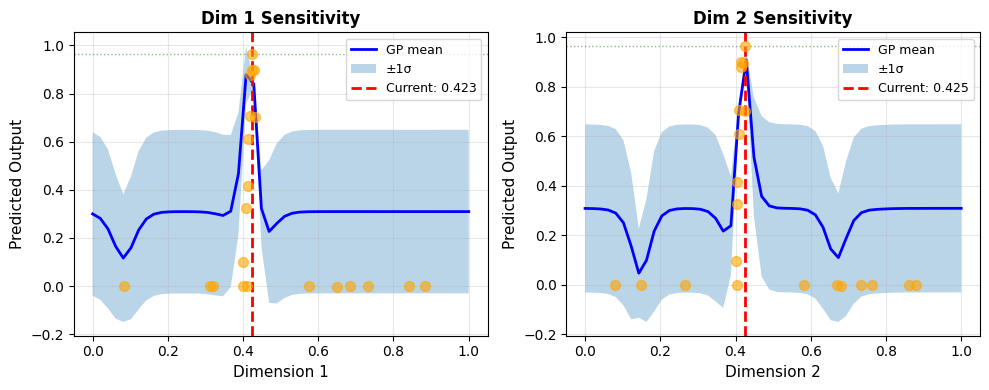



Function 2 (2D) - Sensitivity Analysis
Baseline (best point): [0.700073 0.125362]
Baseline output: 0.613847

Dimension 1: Max gradient = 0.1830 (flat - less important)
Dimension 2: Max gradient = 0.0000 (flat - less important)


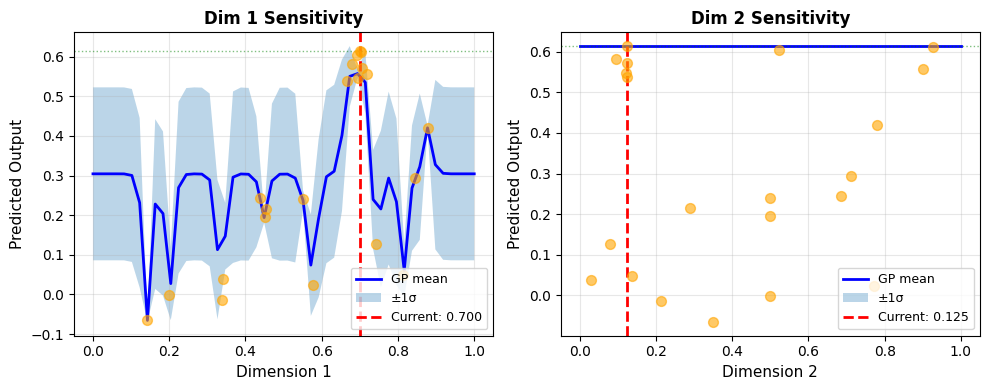



Function 3 (3D) - Sensitivity Analysis
Baseline (best point): [0.347863 0.67242  0.443172]
Baseline output: -0.004616

Dimension 1: Max gradient = 0.0355 (flat - less important)
Dimension 2: Max gradient = 0.0109 (flat - less important)
Dimension 3: Max gradient = 0.0329 (flat - less important)


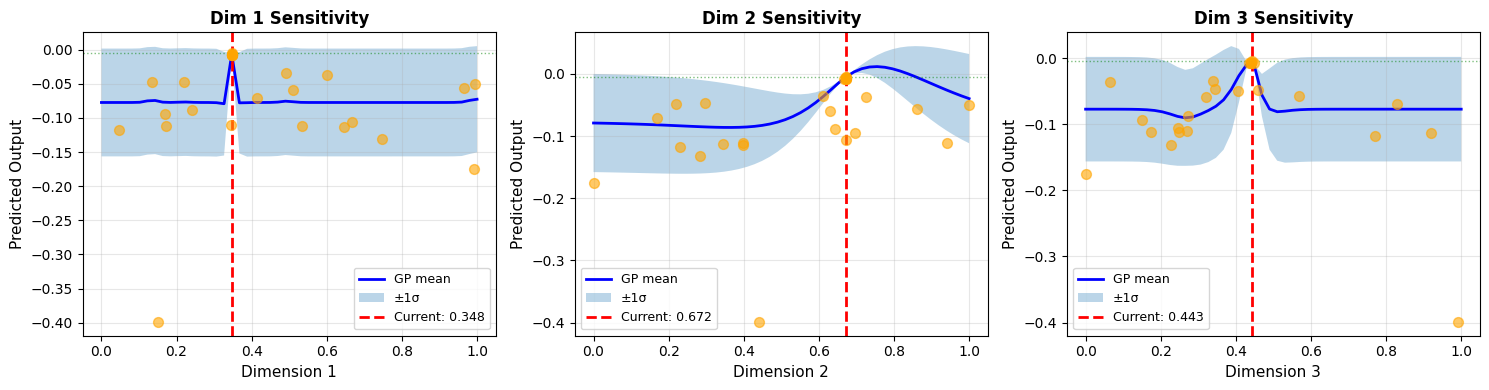



Function 4 (4D) - Sensitivity Analysis
Baseline (best point): [0.41369  0.367443 0.360391 0.413441]
Baseline output: 0.724314

Dimension 1: Max gradient = 0.6380 (flat - less important)
Dimension 2: Max gradient = 1.3603 (steep - important)
Dimension 3: Max gradient = 0.4780 (flat - less important)
Dimension 4: Max gradient = 0.6732 (flat - less important)


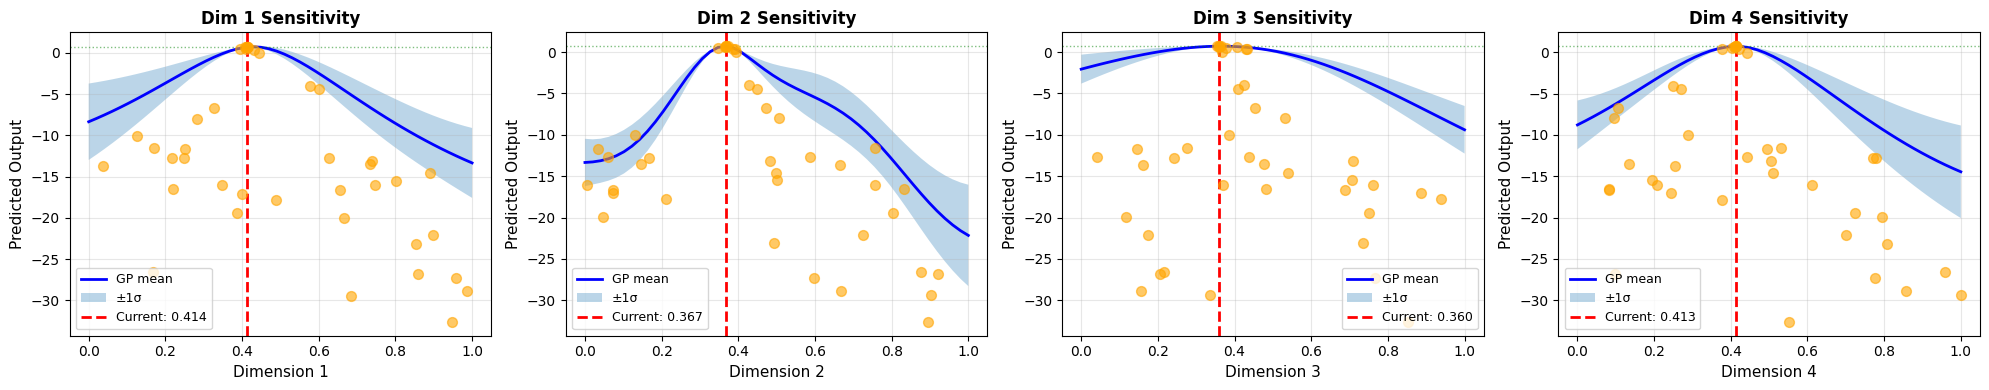



Function 5 (4D) - Sensitivity Analysis
Baseline (best point): [1. 1. 1. 1.]
Baseline output: 8662.482500

Dimension 1: Max gradient = 353.7565 (steep - important)
Dimension 2: Max gradient = 90.4628 (steep - important)
Dimension 3: Max gradient = 371.7013 (steep - important)
Dimension 4: Max gradient = 88.5554 (steep - important)


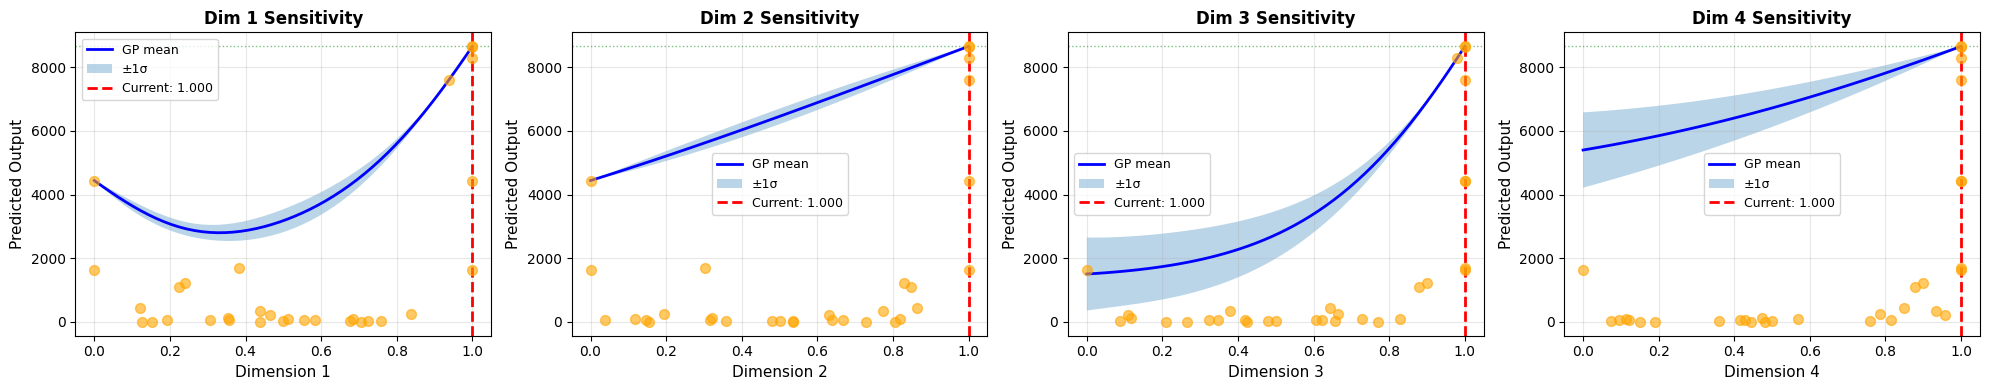



Function 6 (5D) - Sensitivity Analysis
Baseline (best point): [0.755469 0.27558  0.644099 0.672228 0.162862]
Baseline output: -0.520742

Dimension 1: Max gradient = 0.0292 (flat - less important)
Dimension 2: Max gradient = 0.3191 (flat - less important)
Dimension 3: Max gradient = 0.0000 (flat - less important)
Dimension 4: Max gradient = 0.0000 (flat - less important)
Dimension 5: Max gradient = 0.0034 (flat - less important)


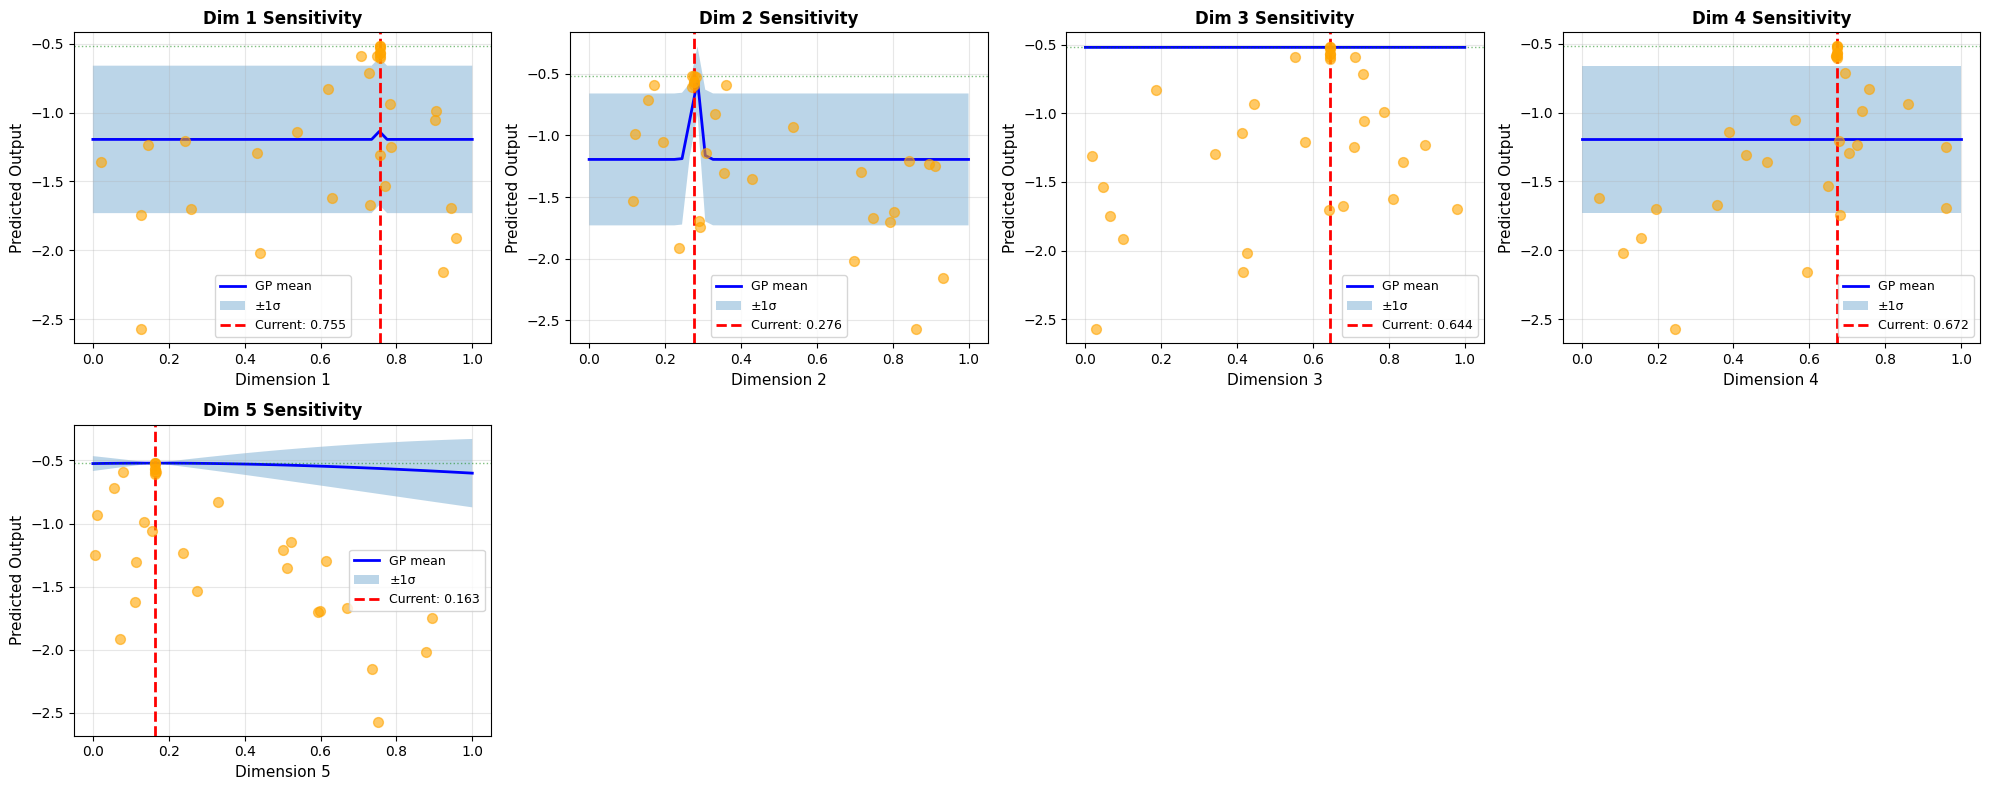



Function 7 (6D) - Sensitivity Analysis
Baseline (best point): [0.       0.306263 0.707844 0.246481 0.405689 0.758028]
Baseline output: 1.878664

Dimension 1: Max gradient = 0.0338 (flat - less important)
Dimension 2: Max gradient = 0.0771 (flat - less important)
Dimension 3: Max gradient = 0.0463 (flat - less important)
Dimension 4: Max gradient = 0.0437 (flat - less important)
Dimension 5: Max gradient = 0.0866 (flat - less important)
Dimension 6: Max gradient = 0.0643 (flat - less important)


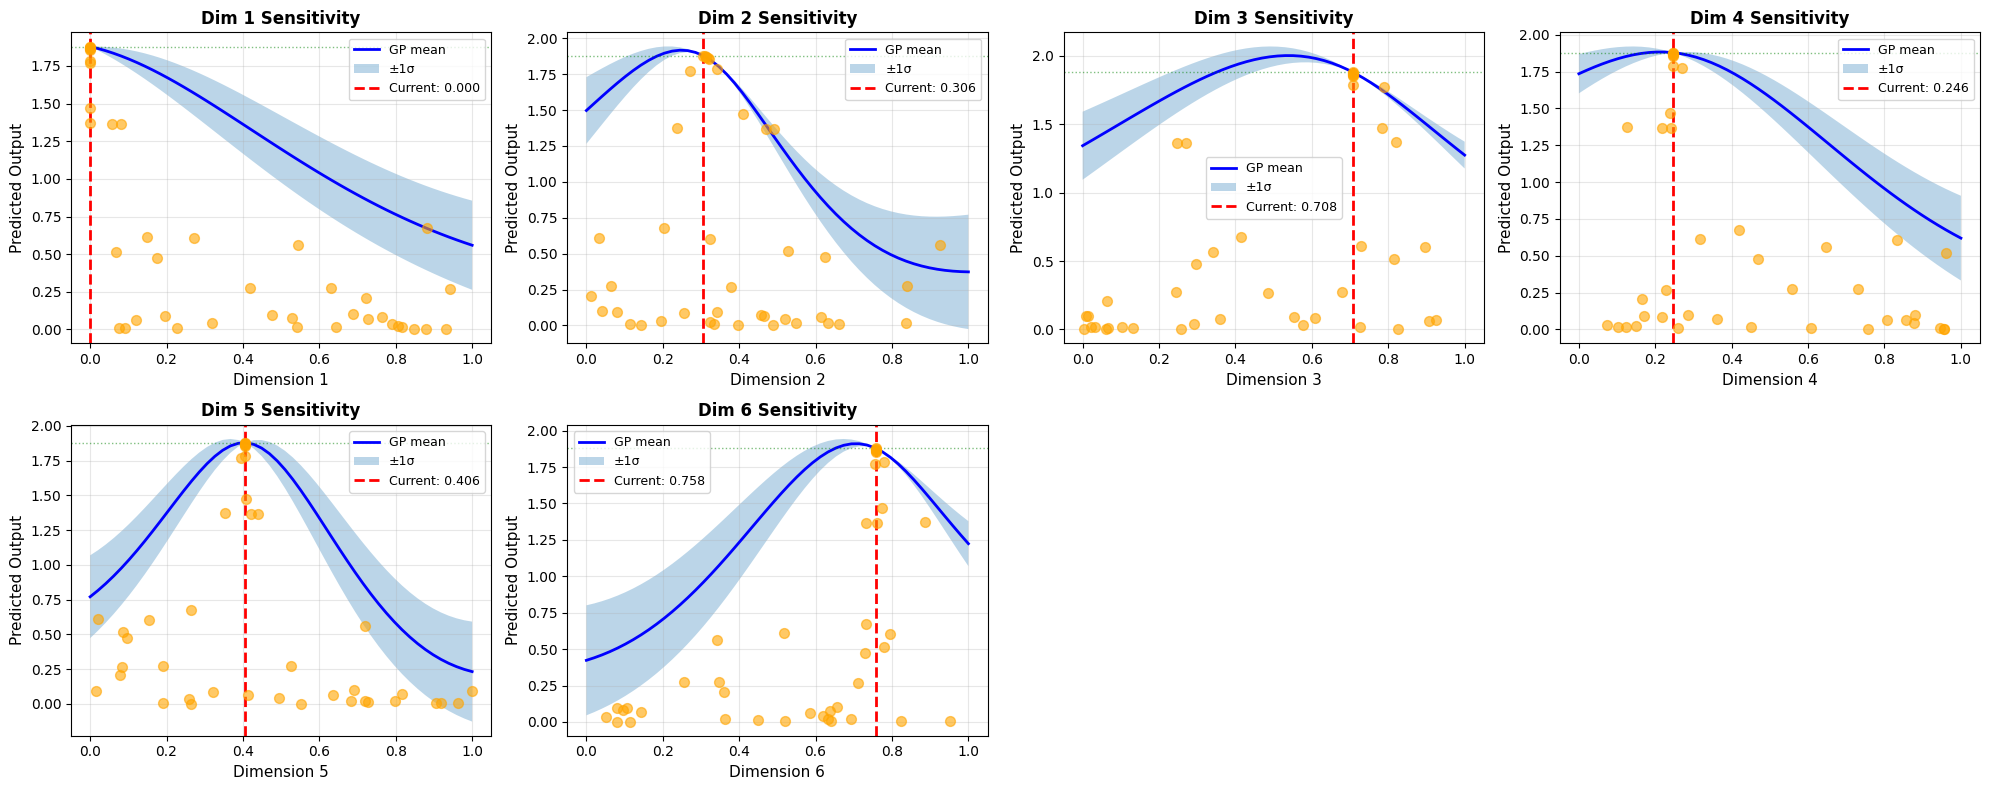



Function 8 (8D) - Sensitivity Analysis
Baseline (best point): [0.107475 0.120302 0.1      0.207071 1.       0.099881 0.18     0.99862 ]
Baseline output: 9.796264

Dimension 1: Max gradient = 0.0686 (flat - less important)
Dimension 2: Max gradient = 0.0314 (flat - less important)
Dimension 3: Max gradient = 0.0991 (flat - less important)
Dimension 4: Max gradient = 0.0218 (flat - less important)
Dimension 5: Max gradient = 0.0115 (flat - less important)
Dimension 6: Max gradient = 0.0228 (flat - less important)
Dimension 7: Max gradient = 0.0562 (flat - less important)
Dimension 8: Max gradient = 0.0000 (flat - less important)


/opt/homebrew/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


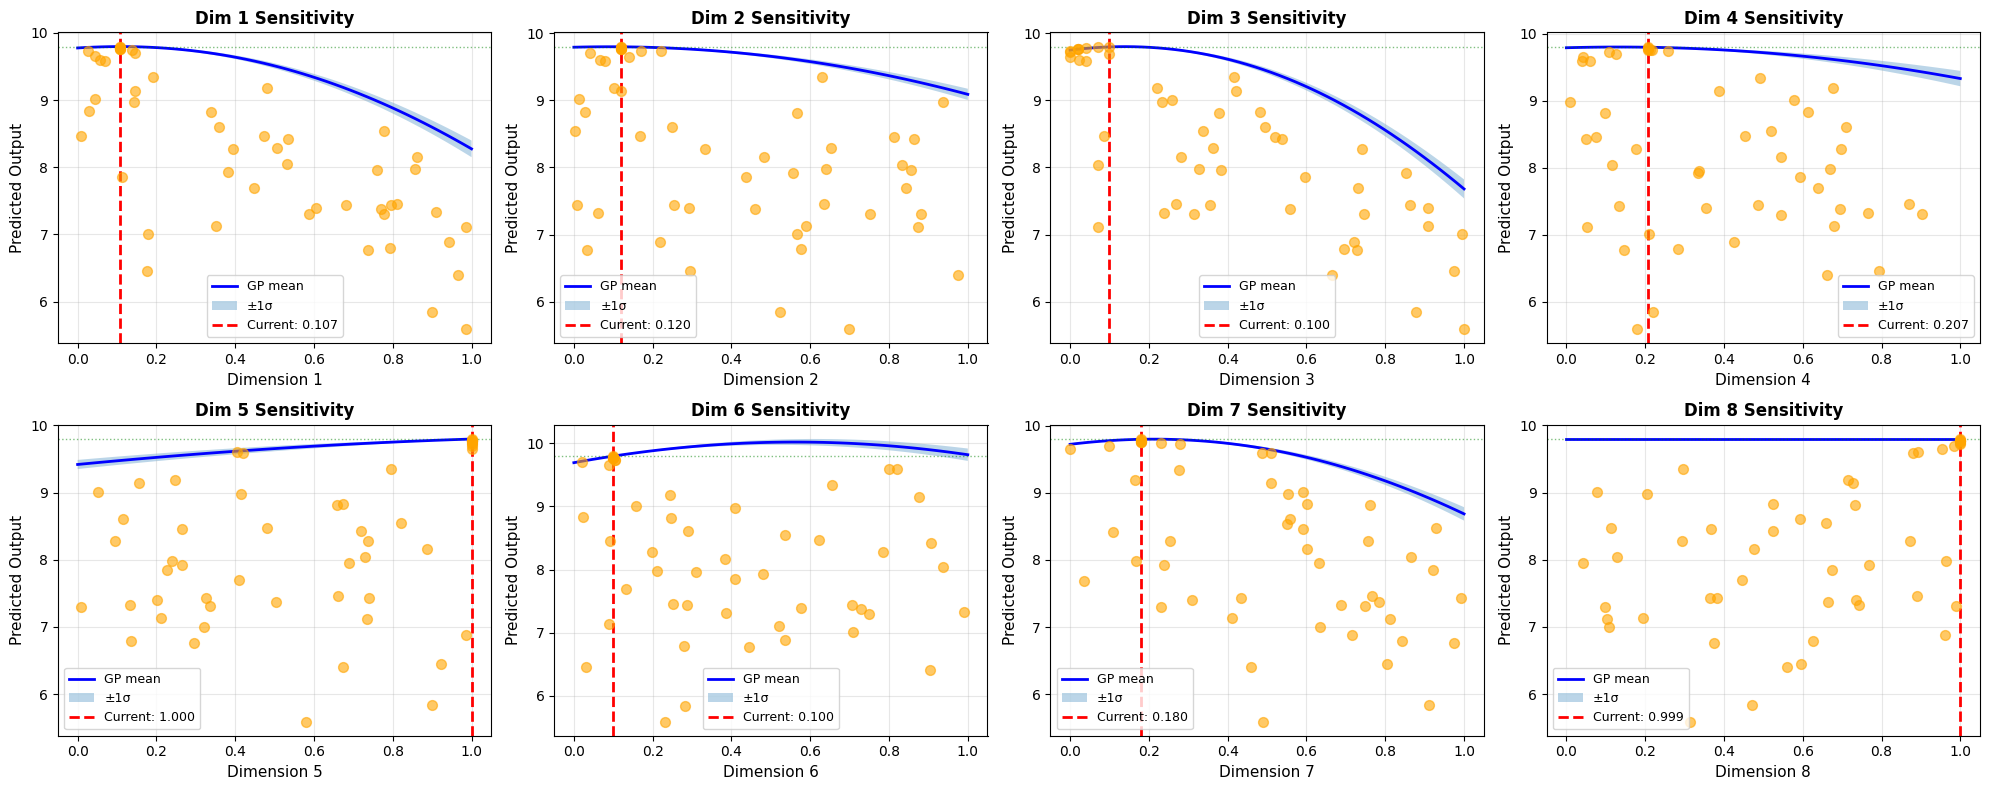

In [5]:
from utils.sensitivity import sensitivity_analysis

for func_id in range(1, 9):
    sensitivity_analysis(func_id, inputs[func_id], outputs[func_id])

## 4. Week 12 Strategy Design

### W11 critical lessons:
- **F1**: dim1+0.010 overshot (0.965→0.702). Use dim2+0.010 from W10 best only.
- **F3**: dim3+0.004 overshot. Halve step to +0.002.
- **F4**: dim2+0.005 failed. Continue proven dim1 decrease trend with tiny step.
- **F5**: Function confirmed symmetric. Best locked at 8662.
- **F6**: Both dim4 directions failed. Try dim5 (last sensitive dim).
- **F7**: 6th consecutive best via dim2-0.003. Continue.
- **F8**: 3rd consecutive dim3 win. Continue.

### Peer insight applied to F2:
Peer reports F2 is bimodal with a second peak. We've exhausted dim1=0.20-0.68 without finding it. W3 tested dim1=0.813→0.048. Try **[0.90, 0.50]** — untested high-dim1 region with different dim2. If this also fails, F2 likely has no second peak accessible through our search.

### Strategy per function:

| F | Strategy | Confidence |
|---|----------|------------|
| F1 | **dim2+0.010 → [0.423, 0.435]** from W10 best | HIGH |
| F2 | **[0.90, 0.50]** — high-dim1 exploration (peer-informed) | GAMBLE |
| F3 | **dim3+0.002 → [0.348, 0.672, 0.445]** from W10 best | HIGH |
| F4 | **dim1-0.001 → [0.4127, 0.367, 0.360, 0.413]** — tiny step in proven direction | HIGH |
| F5 | **[1.0, 1.0, 0.500, 1.0]** — test dim3 mid-range | BOLD |
| F6 | **dim5-0.0001** — last sensitive dim | MODERATE |
| F7 | **dim2-0.003 → [0.0, 0.303, ...]** | HIGH |
| F8 | **dim3+0.030 → [0.107, 0.120, 0.130, ...]** | HIGH |

In [6]:
import warnings
import importlib
import utils.bayesian_optimization
importlib.reload(utils.bayesian_optimization)
from utils.bayesian_optimization import fit_gp, propose_next_point

week12_recommendations = {}

def get_best_point(fid):
    best_idx = np.argmax(outputs[fid])
    return inputs[fid][best_idx].copy()

# ============================================================
# F1: dim2+0.010 from W10 BEST (not W11 which overshot)
# W10 best: [0.423, 0.425] → 0.9648. dim2+0.010 → 0.435.
# W10's dim2+0.010 gave +0.066. W11's dim1+0.010 overshot to 0.702.
# Spike is asymmetric — dim2 tolerates bigger steps.
# ============================================================
best1 = get_best_point(1)  # W10: [0.423, 0.425] → 0.9648
week12_recommendations[1] = np.array([best1[0], best1[1] + 0.010])

# ============================================================
# F2: [0.90, 0.50] — HIGH-DIM1 EXPLORATION (peer-informed)
# Tested dim1: 0.20, 0.45, 0.55 (all dead); 0.68-0.81 (peak at 0.70).
# W3 tested dim1=0.813→0.048. So dim1 just above 0.81 is dead.
# But peer reports bimodality. Second peak must exist somewhere.
# Only untested region: dim1 ∈ [0.82-1.0] at mid-range dim2.
# ============================================================
week12_recommendations[2] = np.array([0.900000, 0.500000])

# ============================================================
# F3: dim3+0.002 from W10 BEST (halve step after overshoot)
# W10: dim3=0.443→-0.0046 (best). W11: dim3=0.447→-0.0082 (overshot).
# Halve step: +0.002 → dim3=0.445.
# ============================================================
best3_idx = None
for i in range(len(outputs[3])):
    if abs(outputs[3][i] - (-0.0046155839830820155)) < 1e-8:
        best3_idx = i
        break
if best3_idx is None:
    best3_idx = np.argmax(outputs[3])
best3 = inputs[3][best3_idx].copy()
week12_recommendations[3] = np.array([best3[0], best3[1], best3[2] + 0.002])

# ============================================================
# F4: dim1-0.001 → 0.4127 (tiny step in proven direction)
# Evidence: dim1=0.416→0.672 (W4), dim1=0.414→0.724 (best).
# Decreasing dim1 improved the score. Continue the trend with
# a TINY step. Avoids W10's dim1=0.409 overshoot risk.
# ============================================================
best4 = get_best_point(4)  # [0.413690, 0.367443, 0.360391, 0.413441] → 0.7243
week12_recommendations[4] = np.array([best4[0] - 0.001, best4[1], best4[2], best4[3]])

# ============================================================
# F5: [1.0, 1.0, 0.5, 1.0] — test dim3 mid-range
# All corners and centre tested. Function is symmetric.
# Try dim3=0.5 with everything else at 1.0.
# ============================================================
week12_recommendations[5] = np.array([1.000000, 1.000000, 0.500000, 1.000000])

# ============================================================
# F6: dim5-0.0001 — last untested sensitive dim
# dim4 both directions failed. dim4=0.672228 is exact optimum.
# dim5 ls=0.0003. 0.0001 = 1/3 length scale.
# ============================================================
best6 = get_best_point(6)  # [0.755469, 0.275580, 0.644099, 0.672228, 0.162862] → -0.5207
week12_recommendations[6] = np.array([
    best6[0],
    best6[1],
    best6[2],
    best6[3],
    best6[4] - 0.0001
])

# ============================================================
# F7: dim2-0.003 → 0.303
# 6 consecutive bests. Same step. 0.303 is 0.032 above danger (0.271).
# ============================================================
best7 = get_best_point(7)  # [0.0, 0.306263, ...] → 1.8787
week12_recommendations[7] = np.array([
    best7[0],
    best7[1] - 0.003,
    best7[2],
    best7[3],
    best7[4],
    best7[5]
])

# ============================================================
# F8: dim3+0.030 → 0.130
# 3 consecutive wins (+0.012, +0.013, +0.008). Keep pushing.
# ============================================================
best8 = get_best_point(8)  # [0.107, 0.120, 0.100, ...] → 9.796
week12_recommendations[8] = np.array([
    best8[0],
    best8[1],
    best8[2] + 0.030,
    best8[3],
    best8[4],
    best8[5],
    best8[6],
    best8[7]
])

# ============================================================
# Sanity check
# ============================================================
print("Week 12 Recommendations")
print("=" * 80)
for fid in range(1, 9):
    X, y = inputs[fid], outputs[fid]
    rec = week12_recommendations[fid]
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gp = fit_gp(X, y)
    pred, pred_std = gp.predict(rec.reshape(1, -1), return_std=True)
    dists = np.linalg.norm(X - rec, axis=1)
    min_dist = np.min(dists)
    best = np.max(y)
    
    strategy = {
        1: "dim2+0.010 from W10 best (dim1 overshot W11) — HIGH",
        2: "[0.90, 0.50] high-dim1 exploration (peer-informed) — GAMBLE",
        3: "dim3+0.002 halved step (W11 overshot) — HIGH",
        4: "dim1-0.001 tiny step in proven direction — HIGH",
        5: "[1,1,0.5,1] test dim3 mid-range — BOLD",
        6: "dim5-0.0001 last sensitive dim (dim4 confirmed) — MODERATE",
        7: "dim2-0.003 → 0.303 (7th best target) — HIGH",
        8: "dim3+0.030 → 0.130 (4th consecutive) — HIGH"
    }
    
    print(f"F{fid} ({X.shape[1]}D)  best={best:.4f}  pred={pred[0]:.4f}±{pred_std[0]:.4f}  dist={min_dist:.4f}  {strategy[fid]}")
    print(f"  point: {rec}")
print("=" * 80)

Week 12 Recommendations
F1 (2D)  best=0.9648  pred=0.3093±0.3755  dist=0.0100  dim2+0.010 from W10 best (dim1 overshot W11) — HIGH
  point: [0.423 0.435]
F2 (2D)  best=0.6138  pred=0.3044±0.2393  dist=0.2098  [0.90, 0.50] high-dim1 exploration (peer-informed) — GAMBLE
  point: [0.9 0.5]
F3 (3D)  best=-0.0046  pred=-0.0058±0.0002  dist=0.0020  dim3+0.002 halved step (W11 overshot) — HIGH
  point: [0.347863 0.67242  0.445172]
F4 (4D)  best=0.7243  pred=0.7100±0.0060  dist=0.0010  dim1-0.001 tiny step in proven direction — HIGH
  point: [0.41269  0.367443 0.360391 0.413441]
F5 (4D)  best=8662.4825  pred=2739.2289±745.9781  dist=0.4800  [1,1,0.5,1] test dim3 mid-range — BOLD
  point: [1.  1.  0.5 1. ]
F6 (5D)  best=-0.5207  pred=-0.9830±0.4907  dist=0.0001  dim5-0.0001 last sensitive dim (dim4 confirmed) — MODERATE
  point: [0.755469 0.27558  0.644099 0.672228 0.162762]
F7 (6D)  best=1.8787  pred=1.8825±0.0008  dist=0.0030  dim2-0.003 → 0.303 (7th best target) — HIGH
  point: [0.       0.3

## 5. Submission Format

In [ ]:
print("=" * 70)
print("WEEK 12 SUBMISSION — COPY THESE VALUES")
print("=" * 70)

for fid in range(1, 9):
    pt = week12_recommendations[fid]
    formatted = '-'.join(f'{x:.6f}' for x in pt)
    print(f"Function {fid}:\t{formatted}")


WEEK 12 SUBMISSION — COPY THESE VALUES
Function 1:	0.423000-0.435000
Function 2:	0.900000-0.500000
Function 3:	0.347863-0.672420-0.445172
Function 4:	0.412690-0.367443-0.360391-0.413441
Function 5:	1.000000-1.000000-0.500000-1.000000
Function 6:	0.755469-0.275580-0.644099-0.672228-0.162762
Function 7:	0.000000-0.303263-0.707844-0.246481-0.405689-0.758028
Function 8:	0.107475-0.120302-0.130000-0.207071-1.000000-0.099881-0.180000-0.998620

SUBMISSION POINTS (array format)
Function 1:	[np.float64(0.423), np.float64(0.435)]
Function 2:	[np.float64(0.9), np.float64(0.5)]
Function 3:	[np.float64(0.347863), np.float64(0.67242), np.float64(0.445172)]
Function 4:	[np.float64(0.41269), np.float64(0.367443), np.float64(0.360391), np.float64(0.413441)]
Function 5:	[np.float64(1.0), np.float64(1.0), np.float64(0.5), np.float64(1.0)]
Function 6:	[np.float64(0.755469), np.float64(0.27558), np.float64(0.644099), np.float64(0.672228), np.float64(0.162762)]
Function 7:	[np.float64(0.0), np.float64(0.303